# Feature Importance

## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
from xgboost import XGBRegressor

# from sklearn.linear_model import LinearRegression
# from sklearn.tree import DecisionTreeRegressor, plot_tree
# from sklearn.model_selection import GridSearchCV

# Make plots render nicely
shap.initjs()

## 2. Load Data

In [2]:
train_df = pd.read_csv("./data/flood_train_scaled.csv")
test_df = pd.read_csv("./data/flood_test_scaled.csv")

TARGET = "FloodProbability"

X_train = train_df.drop(columns=[TARGET])
y_train = train_df[TARGET]

X_test = test_df.drop(columns=[TARGET])
y_test = test_df[TARGET]

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (40000, 20)
Test shape: (10000, 20)


## 3. Train XGBoost Model

In [3]:
xgb_model = XGBRegressor(
    objective="reg:squarederror",
    n_estimators=300,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_weight=3,
    reg_alpha=0.01,
    reg_lambda=1.0,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

## 4. Compute SHAP Values

SHAP values are a feature attribution method that assigns each input variable a numerical contribution to an individual prediction. These contributions represent how much each feature changes the prediction relative to a baseline expectation. Positive values indicate that a feature increases the predicted outcome, while negative values indicate a decrease. Aggregating these values across all observations provides a consistent measure of global feature importance, while still preserving detailed local explanations.

This approach enables both global and local interpretability of complex machine learning models. At a global level, it identifies which factors most strongly influence predictions overall. At a local level, it explains why a specific prediction is high or low by breaking it down into feature-level contributions. This dual capability is particularly important in high-stakes predictive settings, where understanding the reasoning behind individual predictions is as important as overall model accuracy. It also provides a mechanism to validate whether the model is learning meaningful relationships consistent with real-world environmental and infrastructural behavior, rather than relying on spurious correlations.

In [4]:
explainer = shap.Explainer(xgb_model, X_train)

shap_values = explainer(X_test)

100%|===================| 9971/10000 [02:19<00:00]        

## 5. Ranked Feature Importance Table

The following table ranks the top 10 features based on their mean absolute SHAP values, which quantify the average magnitude of each feature’s contribution to the model’s predictions across all observations. Higher values indicate that a feature consistently has a stronger influence on the output, regardless of whether that influence is positive or negative. This produces a global ranking of feature importance grounded in how much each variable affects model behavior on average.

In [5]:
shap_importance = pd.DataFrame(
    {"Feature": X_test.columns, "Importance": np.abs(shap_values.values).mean(axis=0)}
).sort_values(by="Importance", ascending=False)

print("Top 10 SHAP Features:")
display(shap_importance.head(10))

Top 10 SHAP Features:


,Feature,Importance
0,MonsoonIntensity,0.061314
3,Deforestation,0.045219
15,DeterioratingInfrastructure,0.036240
17,WetlandLoss,0.011904
16,PopulationScore,0.010506
4,Urbanization,0.007602
18,InadequatePlanning,0.006185
8,AgriculturalPractices,0.006042
11,DrainageSystems,0.005896
1,TopographyDrainage,0.005732


The most influential drivers of predicted flood probability are population exposure, deforestation level, monsoon intensity, infrastructure degradation, and river management conditions. These variables all have similar importance magnitudes, suggesting that risk is distributed across multiple interacting systems rather than being dominated by a single environmental factor. Natural drivers (such as monsoon intensity) and human-driven land use changes (such as deforestation and urban population pressure) appear equally important, indicating that both environmental forcing and human development patterns jointly shape flood likelihood. The relatively tight clustering of importance values further suggests a stable, multi-factor risk structure rather than a model dominated by a few isolated predictors.

## 6. Bar Plot

This plot visualizes global feature importance using the mean absolute SHAP value for each feature. It ranks variables by the average magnitude of their contribution to model predictions, without distinguishing whether the effect increases or decreases predicted outcomes. It is designed to show which features most strongly influence the model overall.

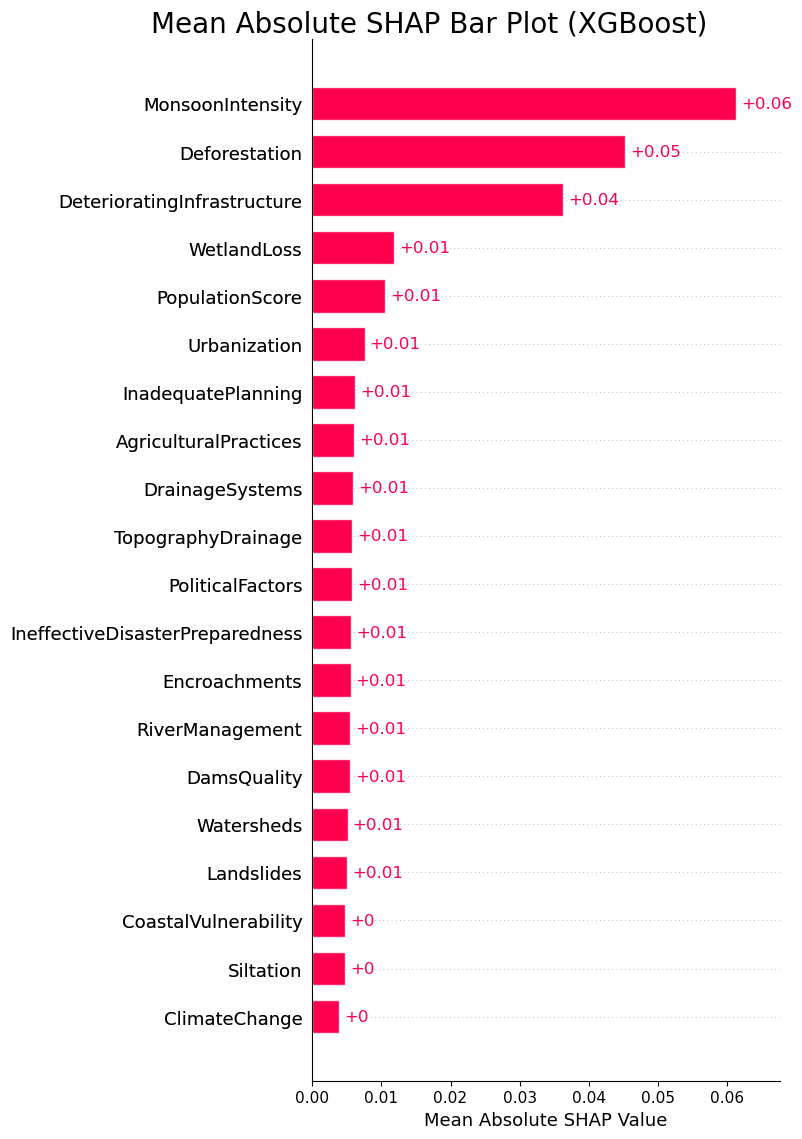

In [6]:
ax = shap.plots.bar(shap_values, max_display=20, show=False)

ax.set_xlabel("Mean Absolute SHAP Value")
ax.set_title("Mean Absolute SHAP Bar Plot (XGBoost)", x=0.25, fontsize=20)

plt.tight_layout()
plt.show()

The strongest contributors to predicted flood probability include population exposure, deforestation levels, monsoon intensity, and infrastructure deterioration. A second tier of influential variables includes river system management, dam conditions, drainage characteristics, and coastal vulnerability. The distribution of importance is relatively smooth, meaning there is no sharp drop-off after the top features. This indicates that flood risk is not driven by a small set of dominant factors but instead emerges from a broad set of environmental, hydrological, and infrastructural conditions.

A key pattern is that both ecological degradation (such as loss of forests and wetlands) and engineered system performance (such as drainage systems and dam conditions) appear prominently. This suggests that structural human interventions and environmental change contribute comparably to risk formation. Variables related to planning quality and disaster preparedness also appear in the mid-to-lower range, indicating that governance and institutional readiness still play a measurable but secondary role in shaping predicted outcomes.

## 7. Beeswarm Plot

This plot shows the distribution of SHAP values for each feature across all observations. Each point represents a single case, with horizontal position indicating the feature’s impact on the prediction and color representing the feature’s value from low to high. This allows simultaneous observation of both the direction and variability of each feature’s effect on the model output.

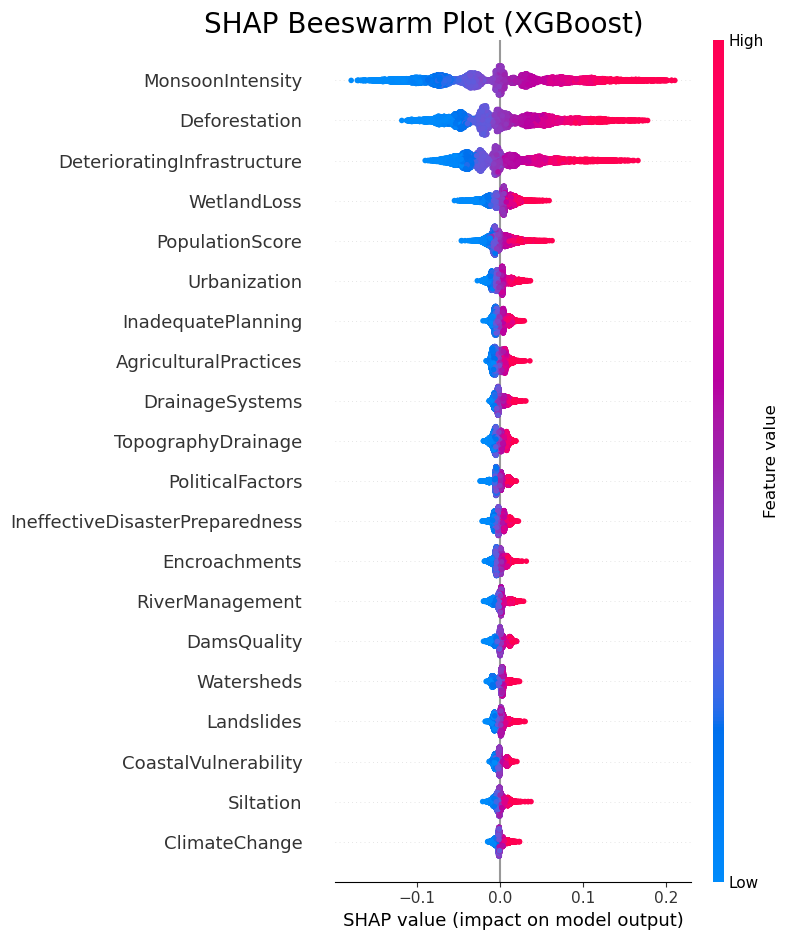

In [7]:
ax2 = shap.plots.beeswarm(shap_values, max_display=20, show=False)

ax2.set_title("SHAP Beeswarm Plot (XGBoost)", x=0.25, fontsize=20)

plt.tight_layout()
plt.show()

Higher levels of population exposure, deforestation, monsoon intensity, and coastal vulnerability are generally associated with increased predicted flood probability, as shown by the concentration of high-value observations pushing predictions upward. In contrast, lower values of these features tend to reduce predicted risk. This indicates a largely monotonic relationship for key environmental and exposure-related variables.

Infrastructure-related variables such as drainage quality, dam conditions, and river management show more variability in their effects, suggesting that their influence depends more heavily on context and interactions with other conditions. Similarly, land-use changes and agricultural practices exhibit wider dispersion, implying that their contribution to risk is not uniform across all settings.

Overall, the beeswam plot highlights that some drivers behave consistently across all observations (e.g., exposure and monsoon strength), while others are highly context-dependent, contributing strongly only under specific combinations of conditions. This structure suggests that flood risk is shaped by both stable environmental gradients and conditional system failures.

## Other Models

In [8]:
# # LINEAR REGRESSION

# # Train Linear Regression Model
# lin_model_lm = LinearRegression()
# lin_model_lm.fit(X_train, y_train)

# # Predictions (for consistency with your workflow)
# lin_pred_lm = lin_model_lm.predict(X_test)

# # SHAP EXPLANATION
# explainer_lm = shap.Explainer(lin_model_lm, X_train)
# shap_values_lm = explainer_lm(X_test)

# # SHAP BAR PLOT
# ax_lm = shap.plots.bar(shap_values_lm, max_display=20, show=False)

# ax_lm.set_xlabel("Mean |SHAP Value| (impact on model output)")
# ax_lm.set_title("Mean Absolute SHAP Bar Plot (Linear Regression)", fontsize=16)

# plt.tight_layout()
# plt.show()

# # SHAP BEESWARM PLOT
# ax_lm = shap.plots.beeswarm(shap_values_lm, max_display=20, show=False)

# ax_lm.set_xlabel("SHAP value (impact on prediction)")
# ax_lm.set_title("SHAP Beeswarm Plot (Linear Regression)", fontsize=16)

# plt.tight_layout()
# plt.show()

In [9]:
# # SPARSE OPTIMAL DECISION TREE

# # MODEL SELECTION (Sparse Optimal Tree via GridSearchCV)
# base_tree_sodt = DecisionTreeRegressor(random_state=42)

# path = base_tree_sodt.cost_complexity_pruning_path(X_train, y_train)
# candidate_alphas = np.unique(np.round(path.ccp_alphas, 6))
# candidate_alphas = candidate_alphas[candidate_alphas >= 0]

# param_grid_sodt = {
#     "max_depth": [2, 3, 4, 5],
#     "min_samples_leaf": [25, 50, 100],
#     "ccp_alpha": candidate_alphas,
# }

# sodt_grid = GridSearchCV(
#     estimator=DecisionTreeRegressor(random_state=42),
#     param_grid=param_grid_sodt,
#     scoring="r2",
#     cv=cv,
#     n_jobs=1,
#     refit=True,
# )

# sodt_grid.fit(X_train, y_train)

# tree_model_sodt = sodt_grid.best_estimator_
# print("Best Sparse Optimal Tree Params:", sodt_grid.best_params_)

# # TRAIN FINAL MODEL
# tree_model_sodt.fit(X_train, y_train)

# tree_pred_sodt = tree_model_sodt.predict(X_test)

# # SHAP EXPLANATION
# explainer_sodt = shap.Explainer(tree_model_sodt, X_train)
# shap_values_sodt = explainer_sodt(X_test)

# # SHAP BAR PLOT
# ax_sodt = shap.plots.bar(shap_values_sodt, max_display=20, show=False)

# ax_sodt.set_xlabel("Mean |SHAP Value| (impact on model output)")
# ax_sodt.set_title("Mean Absolute SHAP Bar Plot (Sparse Optimal Decision Tree)", fontsize=16)

# plt.tight_layout()
# plt.show()

# # SHAP BEESWARM PLOT
# ax_sodt = shap.plots.beeswarm(shap_values_sodt, max_display=20, show=False)

# ax_sodt.set_xlabel("SHAP value (impact on prediction)")
# ax_sodt.set_title("SHAP Beeswarm Plot (Sparse Optimal Decision Tree)", fontsize=16)

# plt.tight_layout()
# plt.show()